<a href="https://colab.research.google.com/github/RONINNNN/Customer-Churn-Prediction-using-Machine-Learning/blob/main/Predicting_Customer_Churn_in_the_Telecom_Industry_project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Churn in the Telecom Industry: A Business Intelligence and Data Mining Approach

**Module:** Business Intelligence and Data Mining  
**Assessment:** Group Project Portfolio  
**Project theme:** Customer churn prediction for a telecom business  
**Dataset:** Telco Customer Churn dataset

This notebook presents a complete business intelligence and data mining project on customer churn in the telecom sector. It combines report writing and practical analysis in one `.ipynb` file, as required. The notebook defines the business problem, justifies the dataset, explores and cleans the data, builds predictive models, evaluates their performance, and turns the results into business recommendations. It also reflects on ethical, privacy, and security issues linked to using customer data for predictive decision-making.

The main aim is to help a telecom company identify customers at risk of leaving and support earlier, better-targeted retention decisions.


## [1] Background of the Customer Churn Problem

Customer churn means customers ending their relationship with a business. In telecommunications, churn is a major issue because services are subscription-based and switching to a competitor is often easy. Even moderate churn can damage revenue because winning a new customer usually costs more than retaining an existing one (Han, Kamber and Pei, 2012).

From a business intelligence perspective, churn is a strong analytical problem because telecom firms already store useful operational data such as contract type, tenure, billing level, service subscriptions, and payment method. When analysed properly, this data can reveal early warning signs of churn and support proactive retention action (Few, 2013).

This project investigates churn prediction using the Telco Customer Churn dataset. The business objective is not only to predict whether a customer is likely to leave, but also to identify the factors most strongly associated with churn and translate them into practical recommendations. The project therefore links predictive modelling with decision support, which is a central aim of business intelligence (Han, Kamber and Pei, 2012).

In [24]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## [2] Dataset Description

### Source of Dataset

The project uses the **Telco Customer Churn** dataset, a widely used public dataset for retention analysis. It contains customer-level records describing demographics, subscribed services, billing information, and churn status.

### Why the dataset is suitable

This dataset is suitable because the target variable directly matches the chosen problem and the feature set reflects realistic telecom business drivers. It includes both numerical and categorical variables, which allows a full workflow of cleaning, encoding, exploratory analysis, and classification modelling. It is also large enough to support meaningful testing while still being manageable in a notebook environment (James *et al*., 2021).

### Key variables

Important variables include:

- **Tenure** – how long the customer has stayed with the company  
- **Contract** – month-to-month, one-year, or two-year agreement  
- **MonthlyCharges** – recurring bill amount  
- **TotalCharges** – cumulative amount paid  
- **InternetService / PhoneService** – subscribed services  
- **PaymentMethod** – billing behaviour indicator  
- **Churn** – target variable showing whether the customer left

These variables support both prediction and business interpretation.

In [25]:
# Load dataset safely from the notebook folder or /mnt/data
possible_files = [
    "telco.csv",
    os.path.join("/mnt/data", "telco.csv"),
]

file_path = None
for f in possible_files:
    if os.path.exists(f):
        file_path = f
        break

if file_path is None:
    raise FileNotFoundError(
        "CSV file not found. Keep the dataset in the same folder as the notebook or in /mnt/data."
    )

df = pd.read_csv(file_path)
print("Loaded file:", file_path)
df.head()

Loaded file: telco.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## [3] Data Cleaning and Feature Engineering

### [3.1] Initial Data Inspection

Before modelling, the dataset is checked for structure, data types, and missing values. This is necessary because machine learning performance depends on data quality (James *et al*., 2021).

A key issue in this dataset is the `TotalCharges` field. Some rows contain blank values, so the column may be read as text instead of numeric. Since this variable is financially important, it must be converted before analysis.

### [3.2] Cleaning strategy

The notebook converts `TotalCharges` to numeric, removes rows with missing values created by blank entries, and reviews categorical fields for consistency. The target variable `Churn` is encoded into binary form so it can be used by classification algorithms.

These steps improve reliability and make the dataset suitable for exploratory analysis and modelling (Han, Kamber and Pei, 2012).

In [26]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values before cleaning:")
print(df.isnull().sum())

Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values before clean

In [27]:
# Clean TotalCharges and remove blank rows
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().copy()

# Remove ID column because it does not help prediction
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())
df.head()

Shape after cleaning: (7032, 20)

Missing values after cleaning:
0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### [3.3] Feature Engineering

After cleaning, the data is transformed into a machine-learning-ready format. One-hot encoding is used for categorical variables so that algorithms can process them correctly without assuming a false numeric order between categories. This is especially important for features such as contract type, internet service, and payment method (James *et al*., 2021).

The target variable is encoded as a binary outcome, allowing the notebook to compare customers who churned with those who remained. The result is a structured feature matrix that supports reproducible modelling while still preserving interpretability.

This stage is important in business intelligence because features must remain understandable. A model is more useful when its most influential variables can be linked back to real customer behaviours that managers can act on.

In [28]:
# Encode target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("Processed feature matrix shape:", X_encoded.shape)
X_encoded.head()

Processed feature matrix shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## [4] Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the structure of the churn problem before formal modelling begins. The purpose is not only to produce charts, but also to detect patterns, support business reasoning, and generate evidence for later recommendations. Good EDA helps answer practical questions such as whether churn is concentrated among newer customers, whether pricing is associated with dissatisfaction, and whether contract structure changes retention risk (Han, Kamber and Pei, 2012).

In this notebook, EDA focuses on the target distribution and several high-value business variables, including contract type, monthly charges, tenure, internet service, and numeric relationships. Each chart is interpreted in relation to the business problem so that the visual analysis contributes to the overall project narrative (Few, 2013).

### [4.1] Target Variable Distribution

The first step is to inspect the balance of the churn variable. This is important because if non-churners are much more common than churners, accuracy on its own may give a misleading impression of model quality. In business terms, a model is only valuable if it identifies a useful proportion of real churners, not if it simply predicts the majority class most of the time.

Understanding the target distribution also helps justify the later use of precision, recall, F1-score, confusion matrices, and ROC analysis.


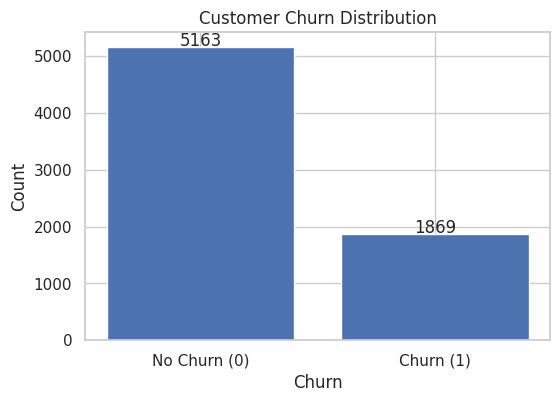

In [29]:
churn_counts = df["Churn"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["No Churn (0)", "Churn (1)"], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 20, str(value), ha="center")
plt.show()

### [4.2] Contract Type and Churn

Contract type is a strong business variable because it reflects customer commitment. Month-to-month customers usually face fewer switching barriers than customers on annual contracts. If churn is visibly highest in the month-to-month group, this supports the idea that contract stability plays an important role in retention.

This insight has immediate strategic value. The company could target suitable month-to-month customers with offers that encourage them to move to longer-term contracts, especially where the model also predicts elevated churn risk.


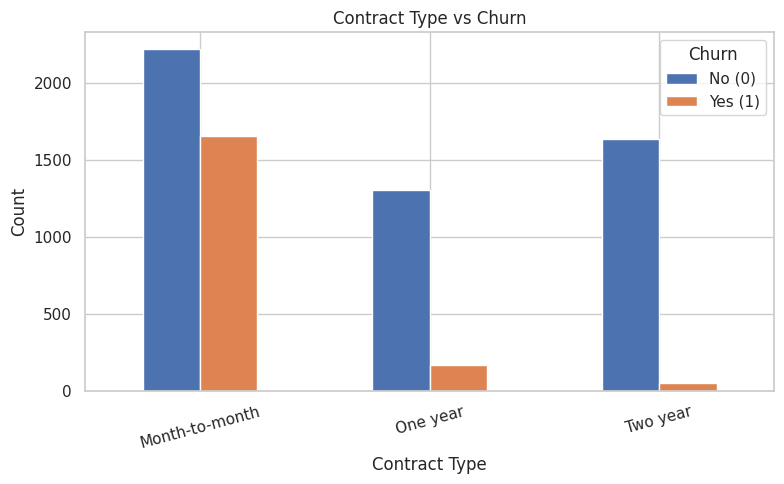

In [30]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(title="Churn", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

### [4.3] Monthly Charges and Churn

Monthly charges show the direct financial burden faced by the customer. If churn is associated with higher monthly charges, the business may have a value-perception problem. Customers may feel that the service they receive does not justify the price they are paying.

This variable is useful because it points toward pricing, bundling, and service-quality strategy. A high-charge customer who is also on a flexible contract may deserve more focused retention attention than a low-charge long-term customer.


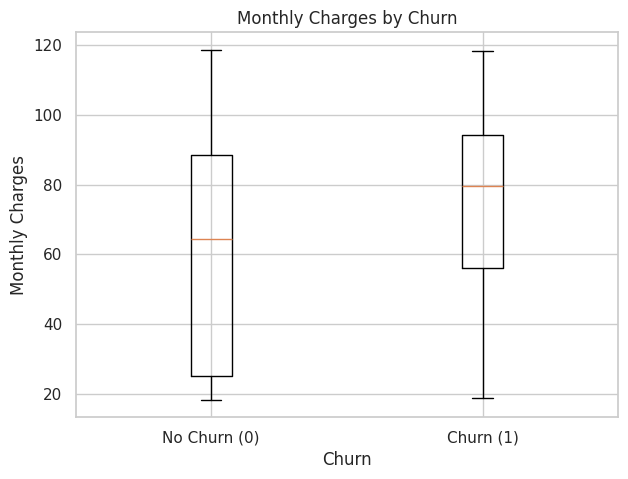

In [31]:
monthly_groups = [
    df.loc[df["Churn"] == 0, "MonthlyCharges"],
    df.loc[df["Churn"] == 1, "MonthlyCharges"]
]
plt.figure(figsize=(7, 5))
plt.boxplot(monthly_groups, labels=["No Churn (0)", "Churn (1)"])
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

### [4.4] Tenure and Churn

Tenure is often one of the strongest retention variables because it measures how long the customer relationship has already lasted. If churn is concentrated among short-tenure customers, it suggests that the early stage of the customer lifecycle is especially risky.

This has strong managerial implications. Rather than treating retention as a late-stage rescue activity, the company may need better onboarding, first-bill communication, and early support to reduce churn during the first months of service.


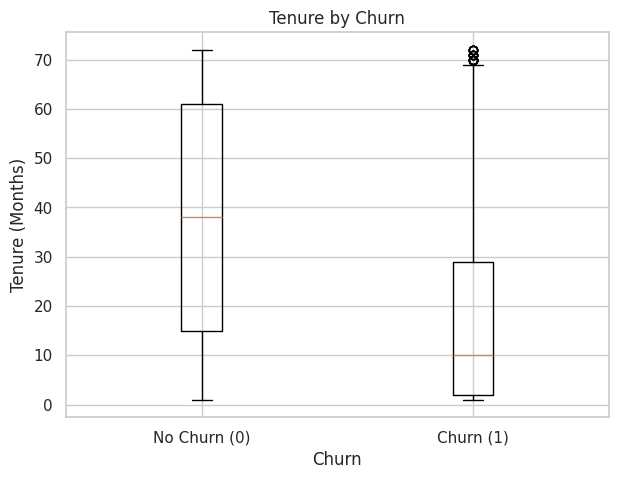

In [32]:
tenure_groups = [
    df.loc[df["Churn"] == 0, "tenure"],
    df.loc[df["Churn"] == 1, "tenure"]
]
plt.figure(figsize=(7, 5))
plt.boxplot(tenure_groups, labels=["No Churn (0)", "Churn (1)"])
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### [4.5] Internet Service and Churn

Analysing churn by internet service type helps reveal whether some product groups are more vulnerable than others. If certain service categories show higher churn, the pattern may reflect different pricing levels, service expectations, or market competition.

This matters because churn management should not be one-dimensional. A retention strategy for fibre customers may differ from a strategy for DSL customers if their risk profile and service expectations are different.


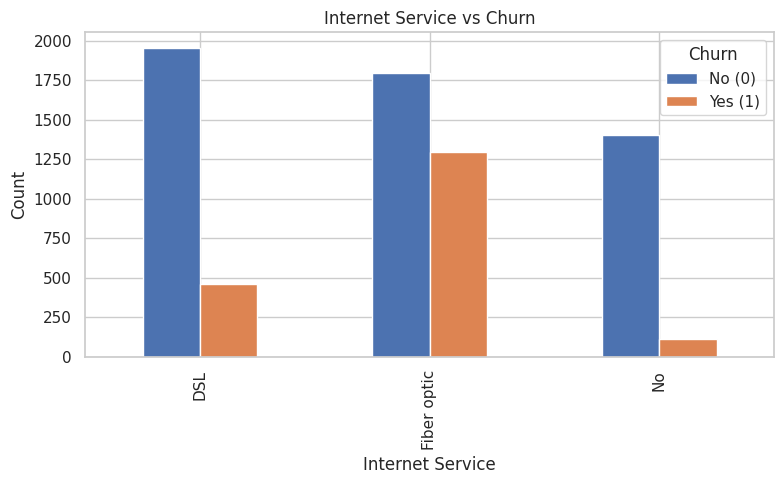

In [33]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])
internet_churn.plot(kind="bar", figsize=(8, 5))
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

### [4.6] Correlation Analysis

Correlation analysis is used to inspect how numeric variables move together. In this dataset, tenure, monthly charges, and total charges are particularly useful because they describe customer duration and financial intensity.

A correlation heatmap does not prove cause and effect, but it helps explain the structure of the dataset. It can also support interpretation later by showing whether important financial variables are closely related or whether they contribute distinct information to the churn story.


In [34]:
corr_target = pd.concat([X_encoded, y], axis=1).corr()["Churn"].sort_values(ascending=False)
corr_target.head(15)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
MonthlyCharges,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033
PhoneService_Yes,0.011691


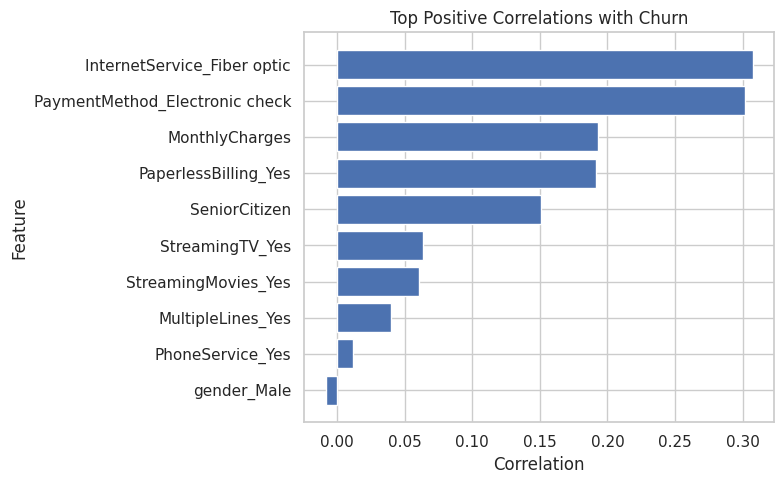

In [35]:
top_corr = corr_target.drop("Churn").head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.title("Top Positive Correlations with Churn")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## [5] Model Development

This project uses supervised classification because churn has two outcomes: a customer either leaves or stays. Two interpretable models are developed: **Logistic Regression** and **Decision Tree**.

These models were chosen because they balance prediction and explanation. Logistic Regression provides a clear baseline and is useful for understanding directional effects. Decision Tree can capture more complex, non-linear patterns and also supports business explanation through its tree structure and feature importance values (James *et al*., 2021; Tan, Steinbach and Kumar, 2019).

The data is split into training and testing sets so that model performance can be assessed on unseen customers rather than only on the data used for learning.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5625, 30)
Testing set shape: (1407, 30)


### [5.1] Logistic Regression Model

Logistic Regression is suitable for churn prediction because it is designed for binary outcomes and produces predicted probabilities. These probabilities can be useful in practice because customers can be ranked by risk rather than being reduced immediately to a simple yes/no label (James *et al*., 2021).

Another benefit is interpretability. The coefficients help show whether variables are linked to increased or reduced churn likelihood, which supports later business discussion. Although Logistic Regression may not capture every complex interaction, it is a strong benchmark because it is stable, well understood, and easy to communicate.

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Check required variables
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression completed")

X_train shape: (5625, 30)
X_test shape: (1407, 30)
Logistic Regression completed


### [5.2] Decision Tree Model

Decision Trees work by splitting the data into branches based on the most informative variables. This method is attractive in business intelligence because its results can often be translated into understandable rules, such as low tenure plus month-to-month contract indicating high churn risk (Tan, Steinbach and Kumar, 2019).

Decision Trees can capture non-linear relationships more naturally than Logistic Regression, but they may also overfit if they become too deep. For that reason, the test-set evaluation is important. Even when they are not the single best predictor, trees can still provide valuable business explanation through their feature importance output (James *et al*., 2021).

In [38]:
from sklearn.tree import DecisionTreeClassifier

# Check required variables
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree completed")

X_train shape: (5625, 30)
X_test shape: (1407, 30)
Decision Tree completed


## [6] Model Evaluation

Model evaluation shows whether the analysis is useful for business decisions. In this notebook, the models are compared using **accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC**.

These measures reflect different priorities. Accuracy gives an overall summary, precision matters when retention action is costly, and recall matters when missing likely churners is risky. F1-score balances precision and recall, while ROC-AUC helps compare ranking performance across thresholds (Fawcett, 2006).

For business use, the preferred model is not simply the one with the highest accuracy, but the one that best fits the organisation’s retention objective.

In [39]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510


### [6.1] Confusion Matrix: Logistic Regression

The confusion matrix shows the exact pattern of correct and incorrect predictions. This is useful because it reveals whether the model is missing too many real churners or generating too many false alarms.

For a telecom business, false negatives are particularly important because they represent churners who were not identified in time. False positives also matter because they may trigger unnecessary retention costs. The confusion matrix therefore translates model performance into operational consequences.


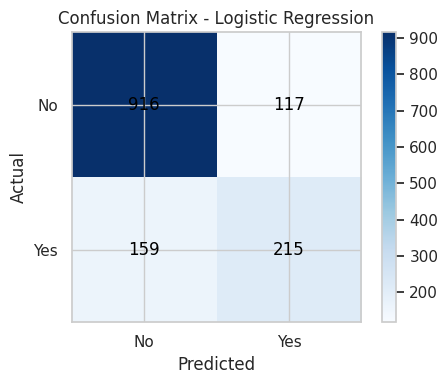

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [40]:
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 4))
plt.imshow(cm_log, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])
for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        plt.text(j, i, cm_log[i, j], ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_log))

### [6.2] Confusion Matrix: Decision Tree

The Decision Tree confusion matrix is interpreted in the same way, but its main value is in comparison with Logistic Regression. If the tree detects more churners but also creates more false positives, the business must decide whether that trade-off is acceptable.

This comparison helps move the notebook from technical scoring into practical judgement.


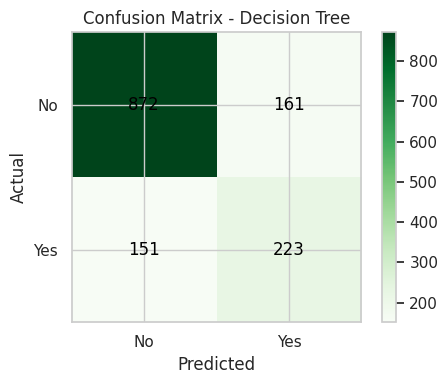

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [41]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(5, 4))
plt.imshow(cm_tree, cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])
for i in range(cm_tree.shape[0]):
    for j in range(cm_tree.shape[1]):
        plt.text(j, i, cm_tree[i, j], ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tree))

### [6.3] ROC Curve Comparison

ROC curves compare the ability of the models to separate churners from non-churners across different thresholds. This is useful because churn models in practice are often used with customised thresholds depending on the cost of intervention.

A stronger ROC profile indicates better separation performance and more flexibility for business deployment. For example, the company could use a lower threshold for a cheap email campaign and a higher threshold for a more expensive personalised offer.


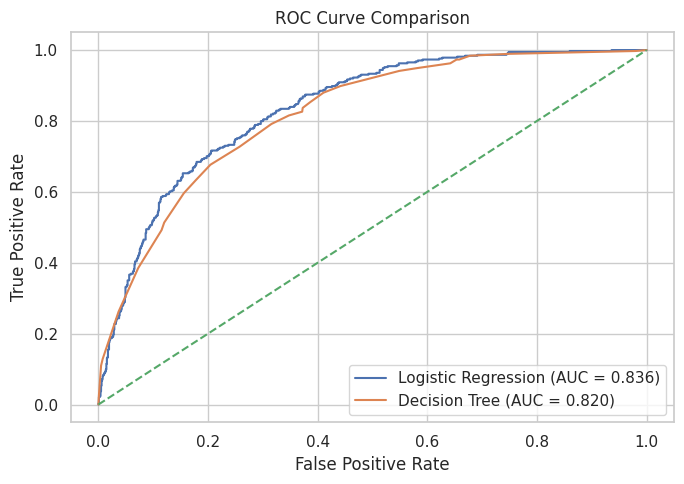

In [42]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## [7] Feature Importance and Interpretation

A strong business intelligence project should explain not only **who** is at risk, but also **why**. Feature interpretation supports that goal by identifying the variables most strongly linked to churn predictions.

In this notebook, Logistic Regression coefficients and Decision Tree feature importance are both examined. If the same variables appear consistently across EDA and modelling, that strengthens confidence in the overall business story (Tan, Steinbach and Kumar, 2019).

### [7.1] Logistic Regression Coefficients

Logistic Regression coefficients provide directional insight into the relationship between predictors and churn. Positive coefficients suggest higher churn risk, while negative coefficients suggest lower risk.

This makes the model especially useful for explanation. Variables such as contract type, tenure, or payment method can be discussed directly in managerial terms, which improves trust in the analysis.


In [43]:
log_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

log_importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


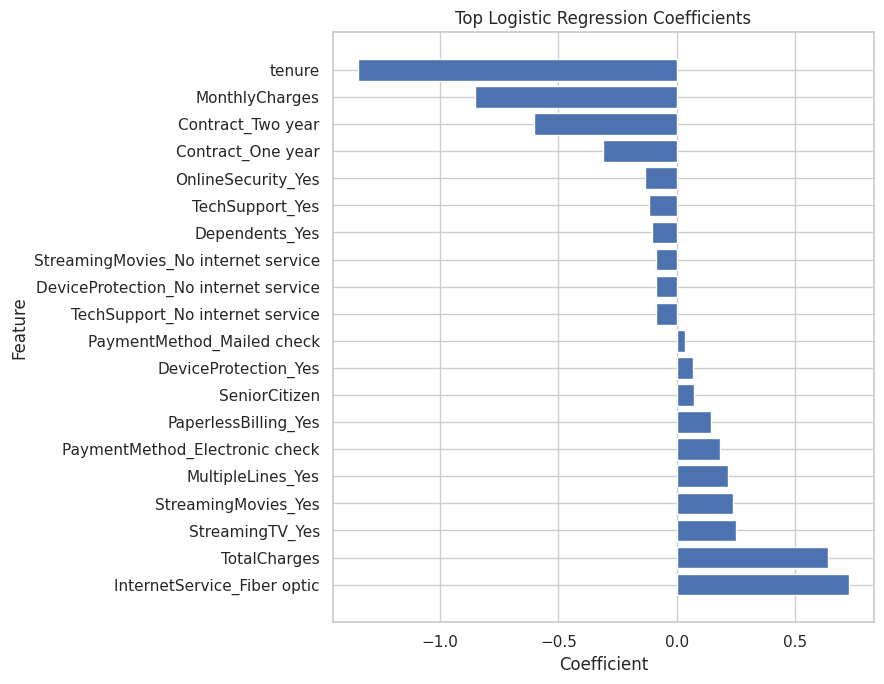

In [44]:
top_log = pd.concat([log_importance.head(10), log_importance.tail(10)])
plt.figure(figsize=(9, 7))
plt.barh(top_log["Feature"], top_log["Coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### [7.2] Decision Tree Feature Importance

Decision Tree feature importance shows which variables the tree relies on most heavily when making splits. This helps identify the strongest practical drivers of churn in the model.

If features such as tenure, monthly charges, and contract type dominate, the business message becomes much clearer: churn is strongly tied to relationship duration, pricing pressure, and customer commitment structure.


In [45]:
tree_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

tree_importance.head(10)

,Feature,Importance
1,tenure,0.441283
10,InternetService_Fiber optic,0.338826
3,TotalCharges,0.033886
28,PaymentMethod_Electronic check,0.026809
12,OnlineSecurity_No internet service,0.026778
2,MonthlyCharges,0.025198
25,Contract_Two year,0.019312
22,StreamingMovies_No internet service,0.015402
13,OnlineSecurity_Yes,0.015138
19,TechSupport_Yes,0.012159


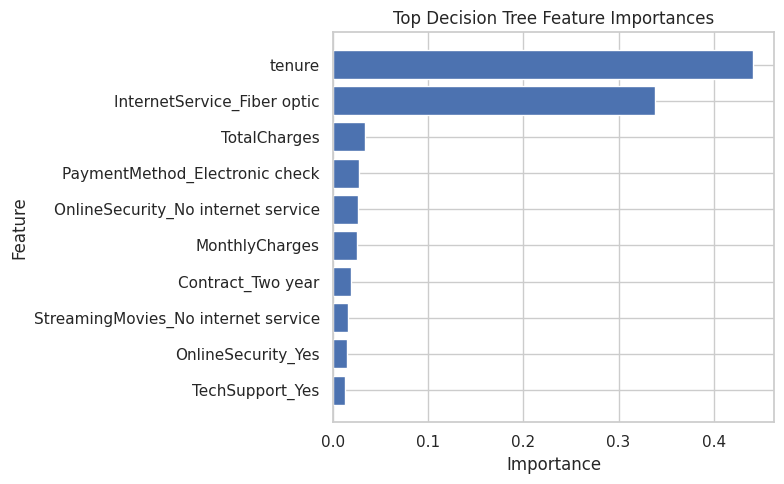

In [46]:
top_tree = tree_importance.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_tree["Feature"][::-1], top_tree["Importance"][::-1])
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## [8] Model Comparison

Model comparison is used to evaluate trade-offs between performance, simplicity, and business usability. If Logistic Regression performs similarly to the Decision Tree, it may be preferred because it is easier to explain and produces risk probabilities directly. If the Decision Tree adds stronger detection or clearer business rules, it may still provide substantial value.

The final choice should therefore consider not only the test metrics but also how the model would be used inside a real retention process. This is important because the assignment rewards justified, critically evaluated solutions rather than mechanical output (James *et al*., 2021).

## [9] Business Insights and Recommendations

The results suggest that churn is strongly linked to **contract type, tenure, and monthly charges**. Month-to-month customers appear more vulnerable, short-tenure customers seem less stable, and higher monthly charges may reduce perceived value.

Based on these findings, the company should:

1. **Strengthen early retention activity** through onboarding, first-month support, and proactive communication.
2. **Target month-to-month customers** with tailored offers that encourage movement to longer contracts.
3. **Review pricing and value perception** for customers paying relatively high monthly charges.
4. **Use churn scores operationally** to prioritise customers for retention campaigns instead of treating all customers the same.

These recommendations are actionable because they are directly linked to model evidence and to variables that a telecom business can influence.

## [10] Limitations

This project has several limitations. The dataset does not include all the variables that might affect churn, such as complaint history, network quality, satisfaction scores, or competitor offers. It is also largely cross-sectional, meaning it does not capture how customer behaviour changes over time.

In addition, the modelling approach is deliberately simple and interpretable. More advanced models might achieve higher predictive accuracy, but they could reduce transparency. Finally, because the dataset is public and educational, the findings should be treated as a realistic analytical exercise rather than a complete production-ready telecom solution.

Recognising these limitations strengthens the credibility of the project because it shows critical reflection rather than overclaiming.

## [11] Ethical, Privacy, and Security Considerations

Using customer data for churn prediction creates ethical, privacy, and security responsibilities.

### Ethics and fairness

Models may produce unfair outcomes if some customer groups are systematically treated as higher risk because of patterns hidden in the data. A business should therefore test performance across relevant customer segments and avoid using churn scores in ways that unfairly disadvantage particular groups (Han, Kamber and Pei, 2012).

### Privacy

Even when data is publicly available or de-identified, customer records can still create privacy risk if combined with other sources. Access should be limited, only necessary fields should be used, and outputs should be reported at an appropriate level.

### Security

If deployed in practice, the system would require secure data storage, controlled access, audit logging, and protection of the model pipeline from unauthorised modification. These controls matter because churn models may influence discounts, interventions, and other commercially sensitive actions.

A responsible organisation should treat predictive accuracy and responsible use as equally important.

## [12] Conclusion

This notebook examined customer churn as a real-world business intelligence problem in the telecom sector. It showed how a public dataset can support the full workflow from problem definition to modelling and business recommendation.

The analysis indicates that churn is closely associated with contract type, tenure, and monthly charges. Logistic Regression and Decision Tree both provided useful predictive and explanatory value, showing that interpretable models can still generate practical business insight.

Overall, the project demonstrates how data mining can support proactive retention strategy when technical results are clearly translated into decisions, risks, and next steps (Han, Kamber and Pei, 2012; James *et al*., 2021).

## [13] References

Fawcett, T. (2006) ‘An introduction to ROC analysis’, *Pattern Recognition Letters*, 27(8), pp. 861–874.

Few, S. (2013) *Information Dashboard Design: Displaying Data for At-a-Glance Monitoring*. 2nd edn. Burlingame: Analytics Press.

Han, J., Kamber, M. and Pei, J. (2012) *Data Mining: Concepts and Techniques*. 3rd edn. Waltham: Morgan Kaufmann.

James, G., Witten, D., Hastie, T. and Tibshirani, R. (2021) *An Introduction to Statistical Learning*. 2nd edn. New York: Springer.

Provost, F. and Fawcett, T. (2013) *Data Science for Business*. Sebastopol: O’Reilly Media.

Tan, P.-N., Steinbach, M. and Kumar, V. (2019) *Introduction to Data Mining*. 2nd edn. Harlow: Pearson.
